# Plotting cooperation index vs. noise

Parses the `.txt` log files produced by `run.sh` (which is itself written by `make_ini_files.py`) and plots the cooperation index against the action / perception noise level for each forgiveness configuration.

Prerequisite: run `bash run.sh` first so the log files are in the working directory.

Expected log-file naming pattern:

```
max_image_<size>_forgive_exp_<exp>_forgive_value_<forgive_value>_action_<action>_assessment_<assessment>_ajd_<ajd>_noise_<noise>.txt
```

Each file is searched for a line of the form `Cooperation index: <value>`.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from collections import OrderedDict

# Line style palette. linestyles_dict is kept as reference; lines_dict and
# colors_dict are what the plotting cell below actually uses.
linestyles_dict = OrderedDict(
    [('solid',               (0, ())),
     ('loosely dotted',      (0, (1, 10))),
     ('dotted',              (0, (1, 5))),
     ('densely dotted',      (0, (1, 1))),

     ('loosely dashed',      (0, (5, 10))),
     ('dashed',              (0, (5, 5))),
     ('densely dashed',      (0, (5, 1))),

     ('loosely dashdotted',  (0, (3, 10, 1, 10))),
     ('dashdotted',          (0, (3, 5, 1, 5))),
     ('densely dashdotted',  (0, (3, 1, 1, 1))),

     ('loosely dashdotdotted', (0, (3, 10, 1, 10, 1, 10))),
     ('dashdotdotted',         (0, (3, 5, 1, 5, 1, 5))),
     ('densely dashdotdotted', (0, (3, 1, 1, 1, 1, 1)))])

colors_dict = OrderedDict(
    [('1', '#ff9933'),
     ('2', '#009999'),
     ('3', '#cc66ff'),
     ('4', '#6699ff'),
     ('5', '#008000'),
     ('6', '#b03060'),
     ('7', '#b03060'),
     ('8', '#b06633')])

lines_dict = OrderedDict(
    [('1', (0, (1, 5))),
     ('2', (0, (5, 5))),
     ('3', (0, (3, 5, 1, 5))),
     ('4', (0, (1, 10))),
     ('5', (0, (5, 10))),
     ('6', (0, (3, 10, 1, 10, 1, 10))),
     ('7', (0, (1, 1))),
     ('8', (0, (5, 1))),
     ('9', (0, (3, 1, 1, 1)))])
ms = 4   # marker size


def get_data(filename):
    """Read a cooperation-index value out of one log file, or None if absent."""
    try:
        with open(filename, 'r') as f:
            lines = f.readlines()
    except FileNotFoundError:
        return None
    for line in lines:
        if "Cooperation index:" in line:
            return float(line.split(":")[1].strip())
    return None


def get_line(size, exp, forgive_value, action, assessment, ajd):
    """Collect (noise, cooperation_index) points for one configuration.

    ``forgive_value`` is the underscore-joined token used in the filename,
    e.g. ``"0.05"`` or ``"0.001_0.5_1_1.355_1.67"``.
    """
    x_values, y_values = [], []
    for noise_value in [0, 0.05, 0.1, 0.15, 0.2]:
        filename = (
            f"max_image_{size}"
            f"_forgive_exp_{exp}"
            f"_forgive_value_{forgive_value}"
            f"_action_{action}"
            f"_assessment_{assessment}"
            f"_ajd_{ajd}"
            f"_noise_{noise_value}.txt"
        )
        value = get_data(filename)
        if value is not None:
            x_values.append(noise_value)
            y_values.append(value)
    return x_values, y_values

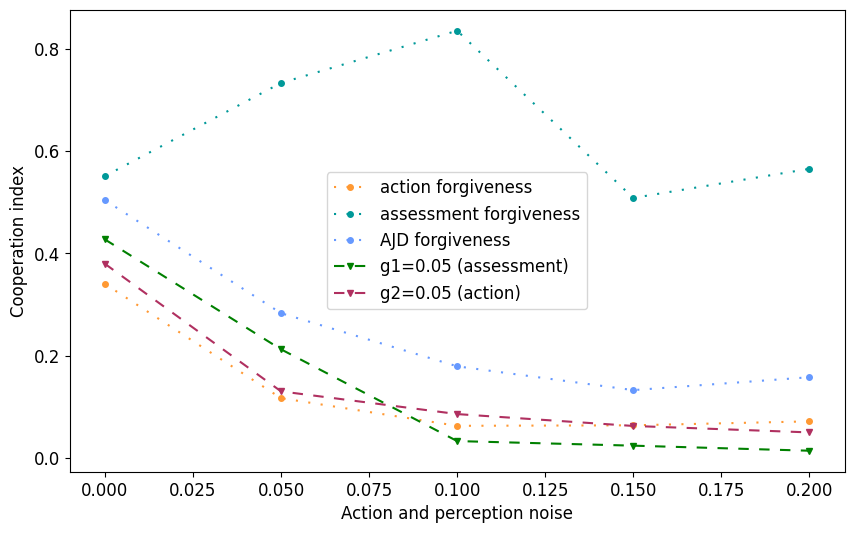

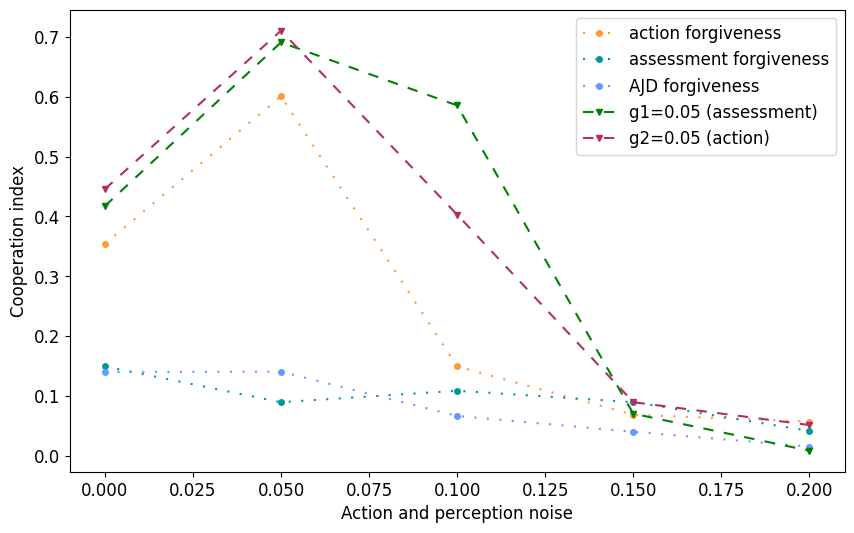

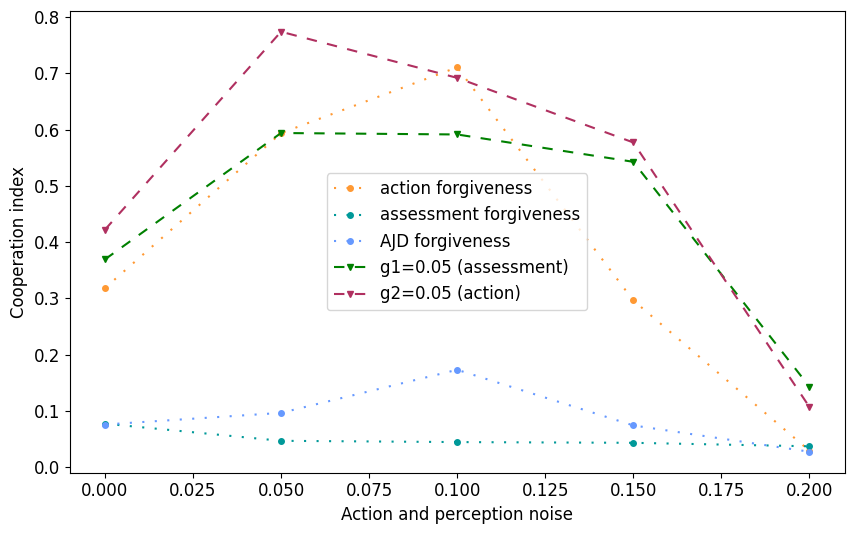

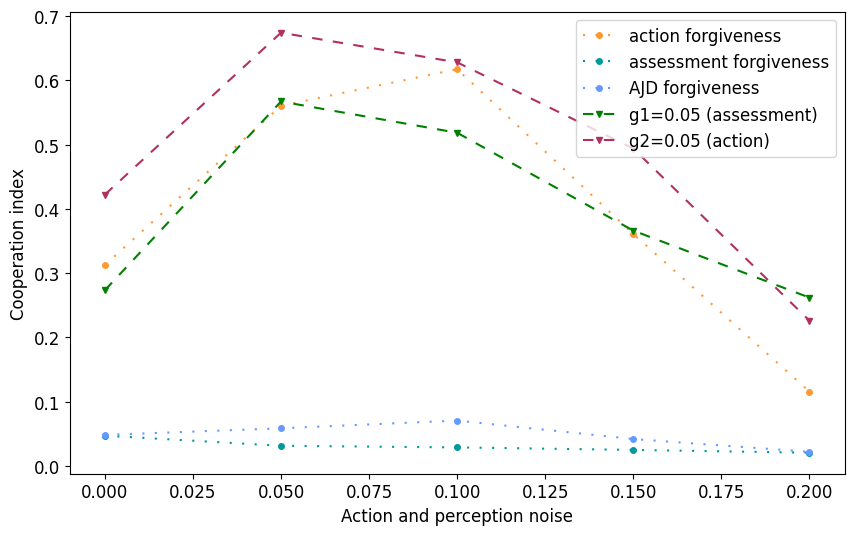

In [3]:
for size in [3,5,7,9]:

    action_forgive = get_line(size,True,"0.001_0.5_1_1.355_1.67",True,False,False)
    assessment_forgive = get_line(size,True,"0.001_0.5_1_1.355_1.67",False,True,False)
    ajd_forgive = get_line(size,True,"0.001_0.5_1_1.355_1.67",False,False,True)
    action_generosity = get_line(size,False,"0.05",True,False,False)
    assessment_generosity = get_line(size,False,"0.05",False,True,False)

    plt.figure(figsize=(10, 6))
    #plt.rcParams.update({'font.size': 12})
    plt.plot(action_forgive[0], action_forgive[1], label='action forgiveness', marker='o',color=colors_dict['1'],markersize=ms,linestyle=lines_dict['1'])

    plt.plot(assessment_forgive[0], assessment_forgive[1], label='assessment forgiveness', marker='o',color=colors_dict['2'],markersize=ms,linestyle=lines_dict['1'])

    plt.plot(ajd_forgive[0], ajd_forgive[1], label='AJD forgiveness', marker='o',markersize=ms,linestyle=lines_dict['1'],color=colors_dict['4'])

    plt.plot(assessment_generosity[0], assessment_generosity[1], label='g1=0.05 (assessment)', marker='v',color=colors_dict['5'],markersize=ms,linestyle=lines_dict['2'])
    
    plt.plot(action_generosity[0], action_generosity[1], label='g2=0.05 (action)', marker='v',color=colors_dict['6'],markersize=ms,linestyle=lines_dict['2'])
    

    
    #plt.title(f"Forgiveness and Generosity for {size} Strategies")
    plt.xlabel("Action and perception noise")
    plt.ylabel("Cooperation index")
    plt.legend()
    #plt.grid(True)
    plt.show()